# Model Fitting

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from scipy.optimize import least_squares

# Resistant Population not Affected by Drug at All

## Load Data

In [10]:
df = pd.read_csv("./data/erlotinib-dose-response.csv")
# The Dose column contains log10(dose).
# Convert it back to actual drug concentration.
df["Dose"] = 10 ** df["log10Dose"]

## Model
Assumes resistant population is not affected at all

Hill function:

$H_S(C)=\frac{C^h}{IC50^h_{50}+C^h}$

### Main training function:

$Y = (1 - \phi)e^{-E_{max,S}t*H_S(C)}$

### Full derivation:
\begin{align}
S(t) &= S_0 e^{g_{\mathrm{Net,S}}t}, \\
R(t) &= R_0 e^{g_{\mathrm{Net,R}}t}.
\end{align}

The initial populations are defined by the resistant fraction $\phi$:

\begin{align}
S_0 &= N_0(1-\phi), \\
R_0 &= N_0\phi.
\end{align}

Assuming a common baseline growth rate $g$ and baseline death rate
$d_0$, the resistant population has

\begin{align}
g_{\mathrm{Net,R}} &= g-d_0.
\end{align}

The sensitive population experiences an additional
drug-induced death rate given by an Emax model:

\begin{align}
d_S(C)
&=
d_0+
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}.
\end{align}

Therefore,

\begin{align}
g_{\mathrm{Net,S}}
&=
g-d_S(C) \\
&=
g-d_0-
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}.
\end{align}

The sensitive population is therefore

\begin{align}
S(t)
&=
N_0(1-\phi)
\exp\left[
\left(
g-d_0-
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}
\right)t
\right].
\end{align}

The resistant population is

\begin{align}
R(t)
&=
N_0\phi
\exp\left[(g-d_0)t\right].
\end{align}

The total treated population is the sum of the two populations:

\begin{align}
N_{\mathrm{treated}}(t)
&=S(t)+R(t) \\
&=
N_0(1-\phi)
\exp\left[
\left(
g-d_0-
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}
\right)t
\right]
+
N_0\phi
\exp\left[(g-d_0)t\right].
\end{align}

Factoring out the common baseline growth term gives

\begin{align}
N_{\mathrm{treated}}(t)
&=
N_0e^{(g-d_0)t}
\left[
(1-\phi)
\exp\left(
-\frac{E_{\max,S}tC^h}
{IC_{50,S}^h+C^h}
\right)
+\phi
\right].
\end{align}

For the untreated control, $C=0$, so the drug-induced death term is zero:

\begin{align}
N_{\mathrm{control}}(t)
&=
N_0e^{(g-d_0)t}.
\end{align}

The experimentally measured relative growth is

\begin{align}
Y(C,\phi)
&=
\frac{N_{\mathrm{treated}}(t)}
{N_{\mathrm{control}}(t)}.
\end{align}

Therefore,

\begin{align}
Y(C,\phi)
&=
\phi
+
(1-\phi)
\exp\left[
-\frac{E_{\max,S}tC^h}
{IC_{50,S}^h+C^h}
\right].
\end{align}

Defining

\begin{align}
E_{\max,t} &= E_{\max,S}t,
\end{align}

the final model becomes

\begin{align}
\boxed{
Y(C,\phi)
=
\phi+
(1-\phi)
\exp\left[
-E_{\max,t}
\frac{C^h}
{IC_{50,S}^h+C^h}
\right]
}
\end{align}

In [11]:
def model(dose, phi, Emax_t, IC50, h):
    """
    Relative population remaining compared with untreated control.

    phi = initial resistant fraction
    1 - phi = initial sensitive fraction

    Emax_t = EmaxS * exposure time
    IC50   = concentration producing half-maximal drug effect
    h      = Hill coefficient
    """

    hill_effect = (
        dose**h /
        (IC50**h + dose**h)
    )

    sensitive_fraction = np.exp(
        -Emax_t * hill_effect
    )

    total_population = (
        phi
        + (1 - phi) * sensitive_fraction
    )

    return total_population

## Extract Data

In [12]:
dose = df["Dose"].values
phi = df["Phi"].values
observed = df["Relative Viability vs Control"].values

## Residual Function

In [13]:
def residuals(log_params):

    # We want log(parameters) so all parameters
    # remain positive.
    Emax_t, IC50, h = np.exp(log_params)

    predicted = model(
        dose,
        phi,
        Emax_t,
        IC50,
        h
    )

    return predicted - observed

## Fit Model

In [14]:
initial_guess = [
    2.0,    # Emax_t
    50.0,   # IC50 (nM)
    2.0     # Hill coefficient
]

result = least_squares(
    residuals,
    np.log(initial_guess)
)

Emax_t_fit, IC50_fit, h_fit = np.exp(result.x)

## Calculate Predictions

In [15]:
df["predicted"] = model(
    df["Dose"].values,
    df["Phi"].values,
    Emax_t_fit,
    IC50_fit,
    h_fit
)

df["residual"] = (
    df["predicted"]
    - df["Relative Viability vs Control"]
)

## Goodness of Fit

In [16]:
RMSE = np.sqrt(
    np.mean(df["residual"] ** 2)
)

SS_res = np.sum(
    df["residual"] ** 2
)

SS_tot = np.sum(
    (
        df["Relative Viability vs Control"]
        - df["Relative Viability vs Control"].mean()
    ) ** 2
)

R_squared = 1 - SS_res / SS_tot

print("\nFITTED PARAMETERS")
print("------------------")
print(f"EmaxS * t = {Emax_t_fit:.6f}")
print(f"IC50      = {IC50_fit:.6f} nM")
print(f"Hill h    = {h_fit:.6f}")

print("\nGOODNESS OF FIT")
print("------------------")
print(f"RMSE      = {RMSE:.6f}")
print(f"R²        = {R_squared:.6f}")


FITTED PARAMETERS
------------------
EmaxS * t = 1.949517
IC50      = 40.447018 nM
Hill h    = 1.943724

GOODNESS OF FIT
------------------
RMSE      = 0.085531
R²        = 0.941704


## Plot Predictions

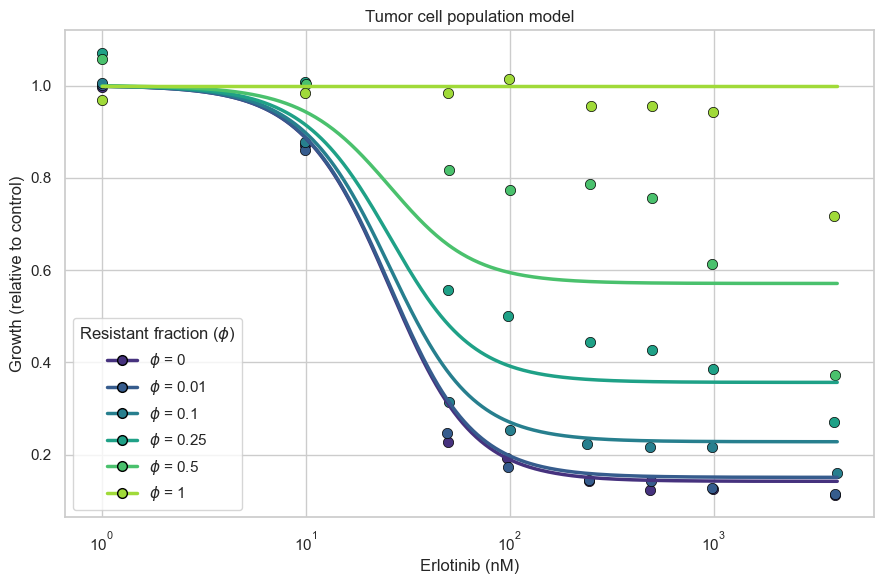

In [21]:
phi_values = sorted(df["Phi"].unique())

# Colors ---------------------------------
palette = sns.color_palette(
    "viridis",
    n_colors=len(phi_values)
)

phi_colors = dict(zip(phi_values, palette))

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(9, 6))


# model dose grid
dose_grid = np.logspace(
    np.log10(df["Dose"].min()),
    np.log10(df["Dose"].max()),
    500
)

for p in phi_values:
    subset = df[df["Phi"] == p]

    # Experimental data
    sns.scatterplot(
        data=subset,
        x="Dose",
        y="Relative Viability vs Control",
        color=phi_colors[p],
        s=55,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    # Model curve
    predicted_curve = model(
        dose_grid,
        p,
        Emax_t_fit,
        IC50_fit,
        h_fit
    )

    sns.lineplot(
        x=dose_grid,
        y=predicted_curve,
        color=phi_colors[p],
        linewidth=2.5,
        ax=ax
    )


# Axis labels and formatting ---------------------------
ax.set_xlabel("Erlotinib (nM)")
ax.set_xscale("log")
ax.set_ylabel("Growth (relative to control)")

ax.set_title(
    "Tumor cell population model"
)


# Legend --------------------------------------------

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color=phi_colors[p],
        markerfacecolor=phi_colors[p],
        markeredgecolor="black",
        linewidth=2.5,
        markersize=7,
        label=fr"$\phi$ = {p:g}"
    )
    for p in phi_values
]

ax.legend(
    handles=handles,
    title=r"Resistant fraction ($\phi$)"
)


plt.tight_layout()
plt.show()

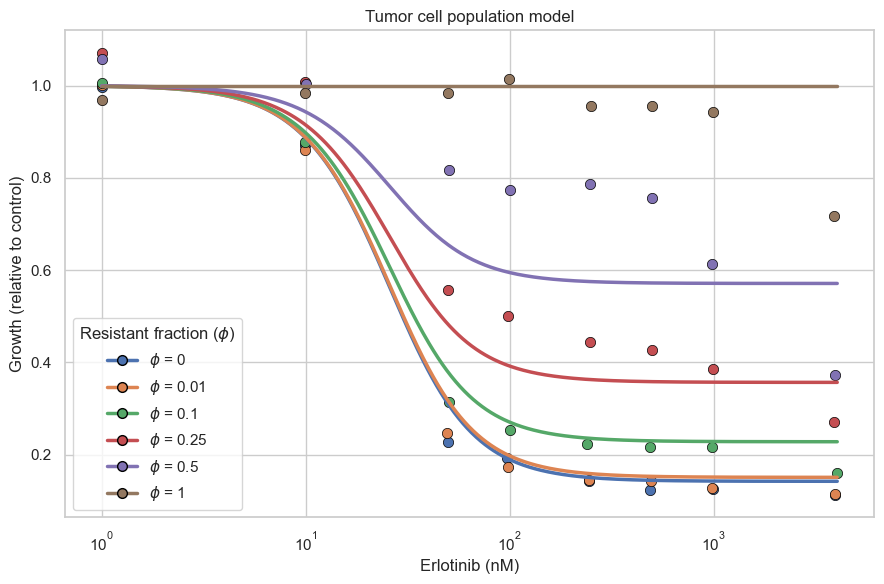

In [22]:
# (Same plot as above but using default categorical color scheme)

phi_values = sorted(df["Phi"].unique())

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

colors = sns.color_palette()

phi_colors = dict(zip(phi_values, colors))

fig, ax = plt.subplots(figsize=(9, 6))

dose_grid = np.logspace(
    np.log10(df["Dose"].min()),
    np.log10(df["Dose"].max()),
    500
)

for p in phi_values:
    subset = df[df["Phi"] == p]

    # Experimental data
    sns.scatterplot(
        data=subset,
        x="Dose",
        y="Relative Viability vs Control",
        color=phi_colors[p],
        s=55,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    # Model curve
    predicted_curve = model(
        dose_grid,
        p,
        Emax_t_fit,
        IC50_fit,
        h_fit
    )

    sns.lineplot(
        x=dose_grid,
        y=predicted_curve,
        color=phi_colors[p],
        linewidth=2.5,
        ax=ax
    )


# Axis labels and formatting --------------------
ax.set_xlabel("Erlotinib (nM)")
ax.set_xscale("log")
ax.set_ylabel("Growth (relative to control)")

ax.set_title(
    "Tumor cell population model"
)


# legend ------------------------------------------
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color=phi_colors[p],
        markerfacecolor=phi_colors[p],
        markeredgecolor="black",
        linewidth=2.5,
        markersize=7,
        label=fr"$\phi$ = {p:g}"
    )
    for p in phi_values
]

ax.legend(
    handles=handles,
    title=r"Resistant fraction ($\phi$)"
)


plt.tight_layout()
plt.show()

# Model that assumes resistant is also affected by drug (but less so)

The resistant population having its own IC50 and response gives the model flexibility to have another falloff point (steepness depending on h) of how/where we get another area of the dose response curve that reacts strongle to drug concentration because that is around the IC50R.

If $A_R = 0$, you get the first model

($A$ is just the product of $E_{max}$ and $t$)

This is not what we've been modeling so far

![Erlotinib Dose Response](./images/erlotinib-dose-response-chart.png)

If you look at the pink data, you'll see a falloff right after $10^3$ concentration of drug. That proves there is an $IC50_R$ because $\phi=1$, therefore any drug response is solely from parameters based on the resistant population

## Load Data

In [24]:
data = pd.read_csv('./data/erlotinib-dose-response.csv')
data["Dose"] = 10**data["log10Dose"]

## Ectract Data

In [25]:
C = data["Dose"].to_numpy()
phi = data["Phi"].to_numpy()
Y_obs = data["Relative Viability vs Control"].to_numpy()

## Define Model

$D_S(C)=\frac{E_{max,S}C^{h_S}}{IC50^{h_S}_{S}+C^{h_S}}$

$D_R(C)=\frac{E_{max,R}C^{h_R}}{IC50^{h_R}_{R}+C^{h_R}}$

Model that is trained:

$Y(C,\phi)=(1-\phi)e^{-D_S(C)t}+\phi e^{-D_R(C)t}$

In [26]:
def model(params, C, phi):
    A_S, IC50_S, h_S, A_R, IC50_R, h_R = params

    # Drug-induced death effect in sensitive population
    effect_S = (
        A_S
        * C**h_S
        / (IC50_S**h_S + C**h_S)
    )

    # Drug-induced death effect in resistant population
    effect_R = (
        A_R
        * C**h_R
        / (IC50_R**h_R + C**h_R)
    )

    # Population response
    Y = (
        (1 - phi) * np.exp(-effect_S)
        +
        phi * np.exp(-effect_R)
    )

    return Y


## Residuals

In [27]:
def residuals(params):

    Y_pred = model(params, C, phi)

    return Y_pred - Y_obs

## Initial Guesses

In [28]:
initial_guess = [
    2.0,    # A_S = Emax_S * t
    0.01,   # IC50_S (nM)
    2.0,    # h_S

    0.5,    # A_R = Emax_R * t
    0.01, # IC50_R (nM)
    2.0     # h_R
]

## Parameter Bounds

In [29]:
lower_bounds = [
    0.0,    # A_S
    0.001,  # IC50_S
    0.1,    # h_S

    0.0,    # A_R
    0.001,  # IC50_R
    0.1     # h_R
]

upper_bounds = [
    20.0,       # A_S
    1e6,        # IC50_S
    20.0,       # h_S

    20.0,       # A_R
    1e6,        # IC50_R
    20.0        # h_R
]

## Fit Model

In [30]:
fit = least_squares(
    residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    max_nfev=100000
)

## Extract Fitted Parameters

In [31]:
A_S, IC50_S, h_S, A_R, IC50_R, h_R = fit.x

print("\nFITTED PARAMETERS")
print("------------------")

print(f"A_S      = {A_S:.6f}")
print(f"IC50_S   = {IC50_S:.6f} nM")
print(f"h_S      = {h_S:.6f}")

print()

print(f"A_R      = {A_R:.6f}")
print(f"IC50_R   = {IC50_R:.6f} nM")
print(f"h_R      = {h_R:.6f}")


FITTED PARAMETERS
------------------
A_S      = 1.859699
IC50_S   = 37.650504 nM
h_S      = 2.038496

A_R      = 0.380317
IC50_R   = 1120.746235 nM
h_R      = 20.000000


## Calculate Predictions

In [32]:
data["Prediction"] = model(
    fit.x,
    C,
    phi
)

## Calculate Goodness of Fit

In [33]:
residual = Y_obs - data["Prediction"].to_numpy()

SSE = np.sum(residual**2)

RMSE = np.sqrt(
    np.mean(residual**2)
)

SST = np.sum(
    (Y_obs - np.mean(Y_obs))**2
)

R2 = 1 - SSE / SST

print("\nGOODNESS OF FIT")
print("----------------")

print(f"SSE  = {SSE:.6f}")
print(f"RMSE = {RMSE:.6f}")
print(f"R²   = {R2:.6f}")


GOODNESS OF FIT
----------------
SSE  = 0.219938
RMSE = 0.067691
R²   = 0.963487


## Smooth Dose Curve Predictions

In [34]:
dose_grid = np.logspace(
    np.log10(C.min()),
    np.log10(C.max()),
    500
)

## Plot predictions

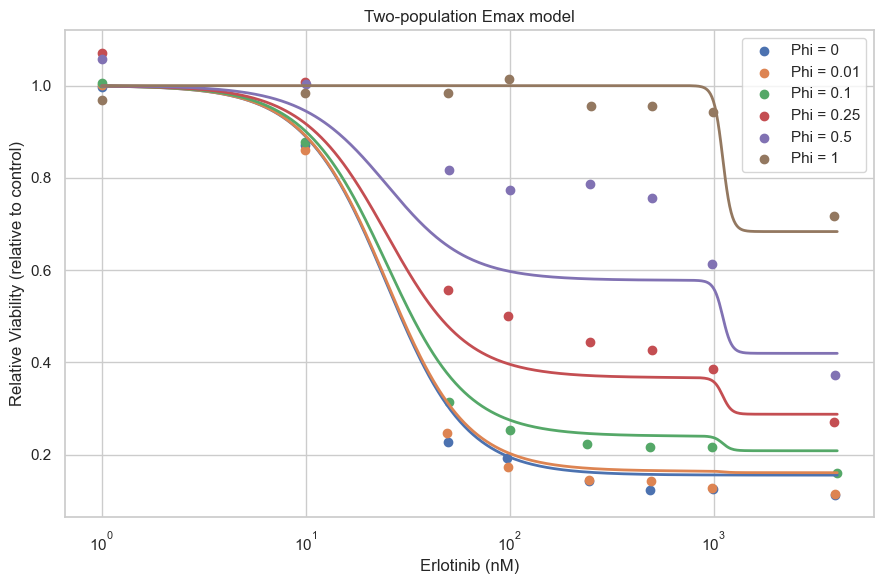

In [35]:
plt.figure(figsize=(9, 6))

for phi_value in sorted(data["Phi"].unique()):

    subset = data[data["Phi"] == phi_value]

    # Experimental points
    plt.scatter(
        subset["Dose"],
        subset["Relative Viability vs Control"],
        label=f"Phi = {phi_value:g}"
    )

    # Model prediction
    prediction = model(
        fit.x,
        dose_grid,
        np.full_like(dose_grid, phi_value)
    )

    plt.plot(
        dose_grid,
        prediction,
        linewidth=2
    )


plt.xscale("log")

plt.xlabel("Erlotinib (nM)")
plt.ylabel("Relative Viability (relative to control)")

plt.title("Two-population Emax model")

plt.legend()

plt.tight_layout()

plt.show()

![Erlotinib Dose Response](./images/erlotinib-dose-response-chart.png)

# Approach #3: Fit phi = 0 and phi = 1 separately as single population models
## Then see how well they combine

## Load Data

In [2]:
df = pd.read_csv("./data/erlotinib-dose-response.csv")
df["Dose"] = 10 ** df["log10Dose"]

## Model

### Assumptions
* E0 is common to sensitive and resistant populations
* N0 and t are not known, but are known to be constant, so we can use a rate*time combination variable.

In [3]:
def emax_death(C, E0, Emax, IC50, h):
    return E0 + Emax * C**h / (IC50**h + C**h)

def pure_viability(C, Emax, IC50, h):
    # E0 cancels against the untreated control.
    return np.exp(-Emax * C**h / (IC50**h + C**h))

def residuals_logparams(theta, C, y):
    # Fit positive parameters in log space.
    Emax, IC50, h = np.exp(theta)
    pred = pure_viability(C, Emax, IC50, h)
    return pred - y


In [4]:
def fit_pure_population(phi, data):
    sub = data[data["Phi"] == phi].copy()
    C = 10.0 ** sub["log10Dose"].to_numpy()
    y = sub["Relative Viability vs Control"].to_numpy()

    # Reasonable starting values in per-assay-time units.
    starts = [
        # Emax, IC50, h
        [1.0, 50.0, 1.0],
        [2.0, 50.0, 1.0],
        [2.0, 100.0, 2.0],
        [3.0, 30.0, 2.0],
        [1.0, 100.0, 3.0],
    ]

    best = None
    for start in starts:
        result = least_squares(
            residuals_logparams,
            np.log(start),
            args=(C, y),
            max_nfev=10000,
        )
        if best is None or np.sum(result.fun**2) < np.sum(best.fun**2):
            best = result

    Emax, IC50, h = np.exp(best.x)
    pred = pure_viability(C, Emax, IC50, h)

    ss_res = np.sum((y - pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot

    return {
        "phi": phi,
        "Emax": Emax,
        "IC50_nM": IC50,
        "h": h,
        "R2": r2,
        "RMSE": np.sqrt(np.mean((y - pred)**2)),
        "fit": best,
        "C": C,
        "y": y,
        "pred": pred,
    }

In [5]:
fit_S = fit_pure_population(0, df)
fit_R = fit_pure_population(1, df)

## Goodness of Fit

In [6]:
def calculate_goodness_of_fit(y_obs, y_pred):
    residual = y_obs - y_pred

    SSE = np.sum(residual**2)

    RMSE = np.sqrt(
        np.mean(residual**2)
    )

    SST = np.sum(
        (y_obs - np.mean(y_obs))**2
    )

    R2 = 1 - SSE / SST

    print("\nGOODNESS OF FIT")
    print("----------------")
    print(f"SSE  = {SSE:.6f}")
    print(f"RMSE = {RMSE:.6f}")
    print(f"R²   = {R2:.6f}")

    return SSE, RMSE, R2

In [7]:
print("\nSENSITIVE POPULATION (phi = 0)")
calculate_goodness_of_fit(
    fit_S["y"],
    fit_S["pred"]
)



SENSITIVE POPULATION (phi = 0)

GOODNESS OF FIT
----------------
SSE  = 0.001807
RMSE = 0.015030
R²   = 0.998061


(0.0018072598509571115, 0.015030218939511125, 0.9980614287719358)

In [8]:
print("\nRESISTANT POPULATION (phi = 1)")
calculate_goodness_of_fit(
    fit_R["y"],
    fit_R["pred"]
)


RESISTANT POPULATION (phi = 1)

GOODNESS OF FIT
----------------
SSE  = 0.002791
RMSE = 0.018678
R²   = 0.953722


(0.0027908015767893124, 0.018677531879203527, 0.9537223143469814)

In [9]:
results = pd.DataFrame([
    {k: fit_S[k] for k in ["phi", "Emax", "IC50_nM", "h", "R2", "RMSE"]},
    {k: fit_R[k] for k in ["phi", "Emax", "IC50_nM", "h", "R2", "RMSE"]},
])

In [10]:
results.head()

,phi,Emax,IC50_nM,h,R2,RMSE
0,0,2.035789e+00,3.350052e+01,2.129371,0.998061,0.015030
1,1,3.282282e+07,1.189204e+11,1.068763,0.953722,0.018678


## Visualize 2 Pure Population Fits

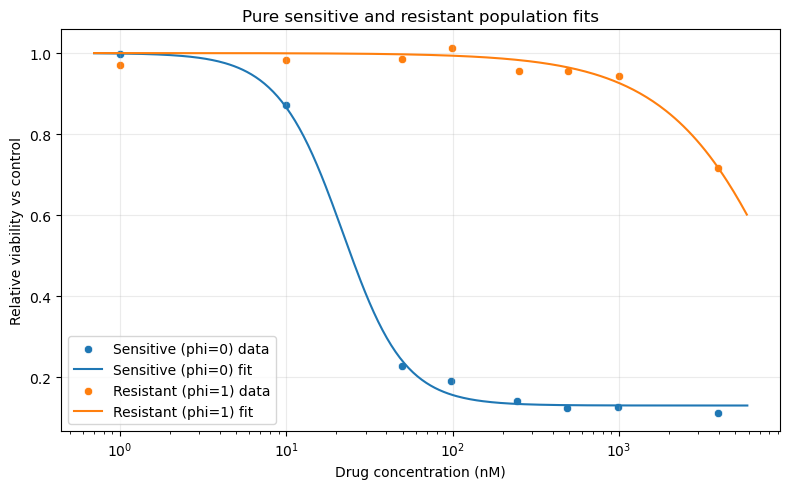

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for fit, label in [(fit_S, "Sensitive (phi=0)"), (fit_R, "Resistant (phi=1)")]:
    xgrid = np.logspace(
        np.log10(min(fit["C"][fit["C"] > 0]) * 0.7),
        np.log10(max(fit["C"]) * 1.5),
        300,
    )
    ygrid = pure_viability(
        xgrid,
        fit["Emax"],
        fit["IC50_nM"],
        fit["h"],
    )

    sns.scatterplot(
        x=fit["C"],
        y=fit["y"],
        ax=ax,
        label=f"{label} data",
    )

    ax.plot(
        xgrid,
        ygrid,
        label=f"{label} fit",
    )

ax.set_xscale("log")
ax.set_xlabel("Drug concentration (nM)")
ax.set_ylabel("Relative viability vs control")
ax.set_title("Pure sensitive and resistant population fits")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Combined Model

### params

In [12]:
Emax_S = fit_S["Emax"]
IC50_S = fit_S["IC50_nM"]
h_S = fit_S["h"]

Emax_R = fit_R["Emax"]
IC50_R = fit_R["IC50_nM"]
h_R = fit_R["h"]

def sensitive_viability(C):
    """
    Relative viability of the pure sensitive population.
    """
    return np.exp(
        -Emax_S * C**h_S /
        (IC50_S**h_S + C**h_S)
    )


def resistant_viability(C):
    """
    Relative viability of the pure resistant population.
    """
    return np.exp(
        -Emax_R * C**h_R /
        (IC50_R**h_R + C**h_R)
    )

In [13]:
def mixed_viability(C, phi):
    V_S = sensitive_viability(C)
    V_R = resistant_viability(C)

    return (
        (1 - phi) * V_S
        + phi * V_R
    )

data = df.copy()


# ------------------------------------------------------------
# 5. Calculate model prediction for every observation
# ------------------------------------------------------------

data["Prediction"] = mixed_viability(
    data["Dose"].to_numpy(),
    data["Phi"].to_numpy()
)


# ------------------------------------------------------------
# 6. Calculate residuals
# ------------------------------------------------------------

data["Residual"] = (
    data["Relative Viability vs Control"]
    - data["Prediction"]
)

## Visualize Full Results

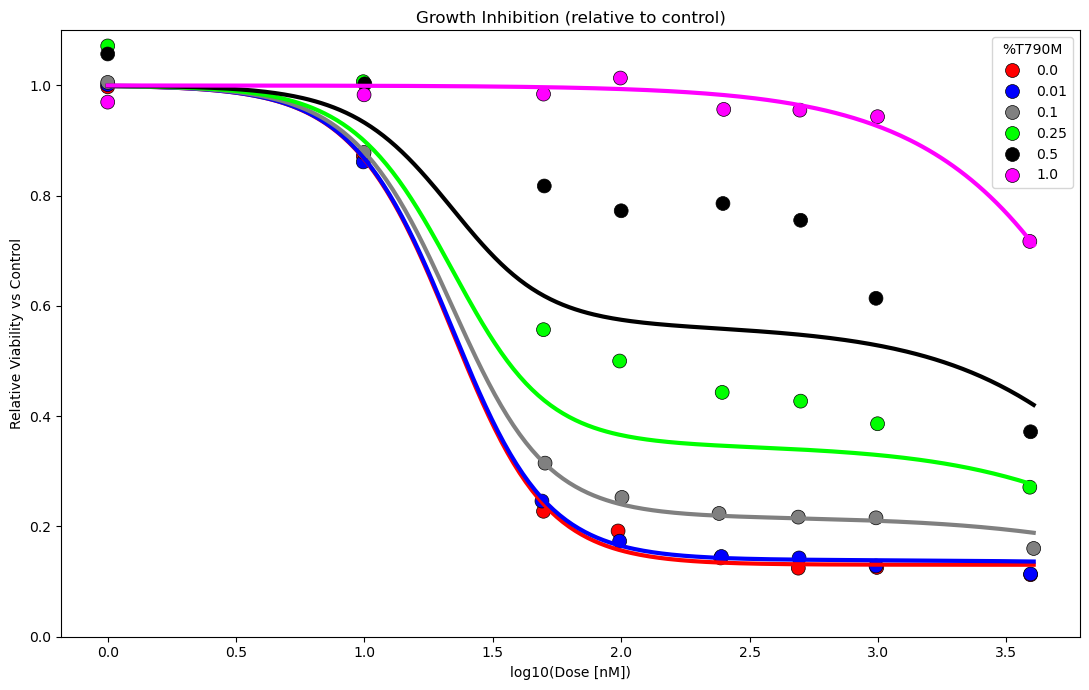

In [14]:
phi_colors = {
    1.00: "#FF00FF",
    0.01: "#0000FF",
    0.25: "#00FF00",
    0.10: "#808080",
    0.50: "black",
    0.0: "#FF0000",
}

plt.figure(figsize=(11, 7))

# Observed data scatterplot
sns.scatterplot(
    data=data,
    x="log10Dose",
    y="Relative Viability vs Control",
    hue="Phi",
    palette=phi_colors,
    hue_order=sorted(phi_colors),
    s=100,
    edgecolor="black",
    linewidth=0.5
)

# Prediction curves for each phi ----------------------------
phi_values = sorted(data["Phi"].unique())

log10_dose_grid = np.linspace(
    data["log10Dose"].min(),
    data["log10Dose"].max(),
    300
)

concentration_grid = 10 ** log10_dose_grid

prediction_grid = []
for phi in phi_values:
    prediction = mixed_viability(
        concentration_grid,
        phi
    )

    temp = pd.DataFrame({
        "log10Dose": log10_dose_grid,
        "Prediction": prediction,
        "Phi": phi
    })

    prediction_grid.append(temp)

prediction_grid = pd.concat(
    prediction_grid,
    ignore_index=True
)

sns.lineplot(
    data=prediction_grid,
    x="log10Dose",
    y="Prediction",
    hue="Phi",
    hue_order=sorted(phi_colors),
    palette=phi_colors,
    linewidth=3,
    legend=False
)

plt.xlabel("log10(Dose [nM])")
plt.ylabel("Relative Viability vs Control")
plt.title("Growth Inhibition (relative to control)")
plt.ylim(0, 1.1)
plt.legend(title="%T790M")

plt.tight_layout()
plt.show()

![Erlotinib Dose Response](./images/erlotinib-dose-response-chart.png)

# Figure S5 Parental (Sensitive) Fitting
[Source](https://pmc.ncbi.nlm.nih.gov/articles/instance/3500629/bin/NIHMS409726-supplement-supplement_1.pdf)

![Parental Time Course](./images/PC-9-parental-cell-proliferation.png)

<!-- ![Parental Time Course](./images/PC-9-ER-proliferation.png) -->

## Constants

In [31]:
# Column names
concentration_col_name = "Erlotinib concentration (uM)"
time_col_name = "time (hrs)"
total_cells_col_name = "Total # Viable Cells (X10^6)"

# Phi - Parental is the sensitive population, and it is only the sensitive.
phi = 0.0

In [32]:
df = pd.read_csv('./data/PC-9-parental-proliferation.csv')

In [33]:
df.head()

,Erlotinib concentration (uM),time (hrs),Total # Viable Cells (X10^6)
0,0,0,0.064066
1,0,48,0.364682
2,0,60,0.652156
3,0,72,0.717864
4,1,0,0.065708


## N0 Acquisition

In [34]:
N0_by_concentration = (
    df[df[time_col_name] == 0]
    .set_index(concentration_col_name)[total_cells_col_name]
    .to_dict()
)

## DeathRate(C) function

In [35]:
def death_rate(concentration, E0, Emax, IC50, h):
    return (
        E0
        + Emax * concentration**h
        / (IC50**h + concentration**h)
    )



## Model

In [36]:
def tumor_model(params, time, concentration, phi):

    (
        g,
        E0,
        Emax_S,
        IC50_S,
        h_S,
        Emax_R,
        IC50_R,
        h_R
    ) = params

    time = np.asarray(time)
    concentration = np.asarray(concentration)

    # --------------------------------------------------------
    # Get N0 for each observation based on its concentration
    # --------------------------------------------------------

    N0 = np.array([
        N0_by_concentration[c]
        for c in concentration
    ])

    # Initial sensitive/resistant populations

    S0 = N0 * (1 - phi)
    R0 = N0 * phi

    # --------------------------------------------------------
    # Drug-dependent death rates
    # --------------------------------------------------------

    death_S = death_rate(
        concentration,
        E0,
        Emax_S,
        IC50_S,
        h_S
    )

    death_R = death_rate(
        concentration,
        E0,
        Emax_R,
        IC50_R,
        h_R
    )

    # --------------------------------------------------------
    # Net growth rates
    # --------------------------------------------------------

    gNet_S = g - death_S
    gNet_R = g - death_R

    # --------------------------------------------------------
    # Population trajectories
    # --------------------------------------------------------

    S = S0 * np.exp(gNet_S * time)
    R = R0 * np.exp(gNet_R * time)

    # Total viable cells

    total = S + R

    return total


## Residuals Calculation

In [37]:
time = df[time_col_name].values
concentration = df[concentration_col_name].values
observed = df[total_cells_col_name].values


def residuals(params):
    predicted = tumor_model(
        params,
        time,
        concentration,
        phi
    )

    return predicted - observed

## Initial Guesses and Bounds

In [38]:
# Parameters being FIT:
#
# g
# E0
# Emax_S
# IC50_S
# h_S
# Emax_R
# IC50_R
# h_R

initial_guess = [
    0.05,     # g
    0.005,    # E0

    0.05,     # Emax_S
    1.0,      # IC50_S
    2.0,      # h_S

    0.01,     # Emax_R
    5.0,      # IC50_R
    2.0       # h_R
]

lower_bounds = [
    0.0,      # g
    0.0,      # E0

    0.0,      # Emax_S
    1e-6,     # IC50_S
    0.1,      # h_S

    0.0,      # Emax_R
    1e-6,     # IC50_R
    0.1       # h_R
]

upper_bounds = [
    1.0,      # g
    1.0,      # E0

    1.0,      # Emax_S
    100.0,    # IC50_S
    10.0,     # h_S

    1.0,      # Emax_R
    100.0,    # IC50_R
    10.0      # h_R
]

## Fit Model

In [39]:
fit = least_squares(
    residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    method="trf"
)

best_params = fit.x

In [40]:
parameter_names = [
    "growth_rate",
    "E0",
    "Emax_S",
    "IC50_S",
    "h_S",
    "Emax_R",
    "IC50_R",
    "h_R"
]

parameter_table = pd.DataFrame({
    "Parameter": parameter_names,
    "Estimate": best_params
})

print("\nFitted parameters")
print("=================")

print(parameter_table.to_string(index=False))

print(f"\nPhi = {phi}")

print("\nN0 values:")
for concentration_value, N0 in N0_by_concentration.items():
    print(f"{concentration_value} uM: {N0:.6f}")

parameter_table.head(10)


Fitted parameters
  Parameter  Estimate
growth_rate  0.061226
         E0  0.026250
     Emax_S  0.046261
     IC50_S 99.999804
        h_S  0.171993
     Emax_R  0.010000
     IC50_R  5.000000
        h_R  2.000000

Phi = 0.0

N0 values:
0 uM: 0.064066
1 uM: 0.065708
3 uM: 0.062423
10 uM: 0.064066
20 uM: 0.064066


,Parameter,Estimate
0,growth_rate,0.061226
1,E0,0.026250
2,Emax_S,0.046261
3,IC50_S,99.999804
4,h_S,0.171993
5,Emax_R,0.010000
6,IC50_R,5.000000
7,h_R,2.000000


## Goodness of Fit

In [41]:
df["predicted"] = tumor_model(
    best_params,
    df[time_col_name].values,
    df[concentration_col_name].values,
    phi
)

df["residual"] = (
    df[total_cells_col_name] - df["predicted"]
)

SSE = np.sum(
    (df[total_cells_col_name] - df["predicted"])**2
)

SST = np.sum(
    (df[total_cells_col_name] -df[total_cells_col_name].mean())**2
)

R_squared = 1 - SSE / SST

RMSE = np.sqrt(
    np.mean(
        (df[total_cells_col_name] - df["predicted"])**2
    )
)

print("\nGoodness of fit:")
print(f"SSE  = {SSE:.6f}")
print(f"RMSE = {RMSE:.6f}")
print(f"R²   = {R_squared:.4f}")


Goodness of fit:
SSE  = 0.052697
RMSE = 0.051331
R²   = 0.9114


## Visualize Predictions

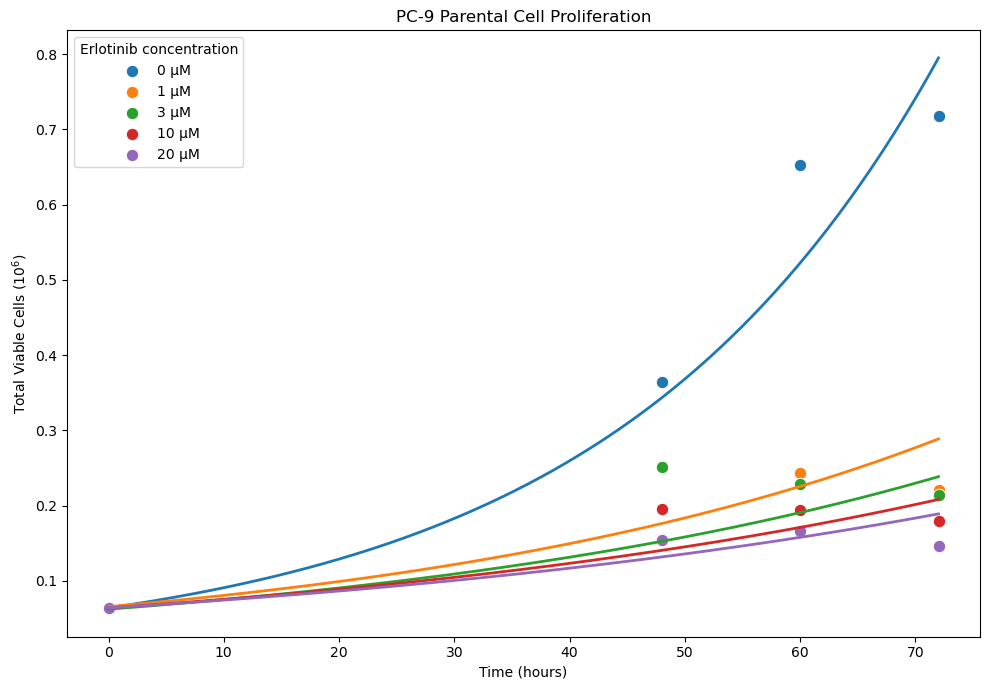

In [42]:
# sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

concentrations = sorted(df[concentration_col_name].unique())

# Get Seaborn's default color cycle
colors = sns.color_palette()

# Create mapping: concentration -> color
color_map = {
    concentration: colors[i % len(colors)]
    for i, concentration in enumerate(concentrations)
}

for concentration_value in concentrations:

    subset = df[
        df[concentration_col_name] == concentration_value
    ]

    sns.scatterplot(
        data=subset,
        x=time_col_name,
        y=total_cells_col_name,
        color=color_map[concentration_value],
        s=80,
        label=f"{concentration_value} µM"
    )

time_grid = np.linspace(
    df[time_col_name].min(),
    df[time_col_name].max(),
    300
)

for concentration_value in concentrations:

    model_values = tumor_model(
        best_params,
        time_grid,
        np.full_like(time_grid, concentration_value),
        phi
    )

    plt.plot(
        time_grid,
        model_values,
        color=color_map[concentration_value],
        linewidth=2
    )


plt.xlabel("Time (hours)")
plt.ylabel("Total Viable Cells ($10^6$)")

plt.title(
    f"PC-9 Parental Cell Proliferation"
)

plt.legend(
    title="Erlotinib concentration"
)

plt.tight_layout()
plt.show()

![Parental Time Course](./images/PC-9-parental-cell-proliferation.png)

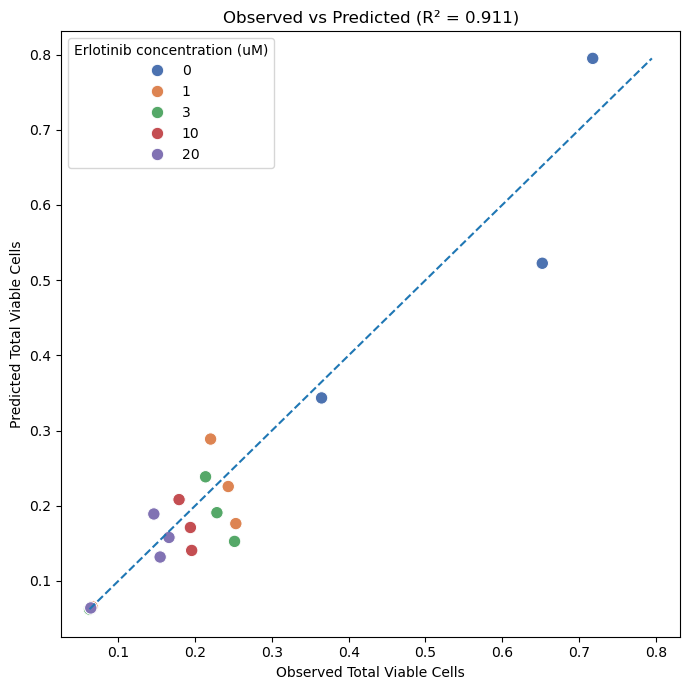

In [43]:
concentrations = sorted(df[concentration_col_name].unique())

colors = sns.color_palette("deep", n_colors=len(concentrations))

color_map = dict(zip(concentrations, colors))

plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=df,
    x=total_cells_col_name,
    y="predicted",
    hue=concentration_col_name,
    palette=color_map,
    s=80
)

min_value = min(
    df[total_cells_col_name].min(),
    df["predicted"].min()
)

max_value = max(
    df[total_cells_col_name].max(),
    df["predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Observed Total Viable Cells")
plt.ylabel("Predicted Total Viable Cells")
plt.title(f"Observed vs Predicted (R² = {R_squared:.3f})")

plt.tight_layout()
plt.show()

# Figure S5 Resistant Fitting
[Source](https://pmc.ncbi.nlm.nih.gov/articles/instance/3500629/bin/NIHMS409726-supplement-supplement_1.pdf)

![Parental Time Course](./images/PC-9-ER-proliferation.png)

In [44]:
# THE TWO DIFFERENCE FOR THE BELOW
# 1. Phi now being 1 because this is a pure population of just
# 2. Using the PC-9/ER Proliferation dataset. The ER stands for Erlotinib resistant

phi = 1
df = pd.read_csv('./data/PC-9-ER-proliferation.csv')

In [45]:
N0_by_concentration = (
    df[df[time_col_name] == 0]
    .set_index(concentration_col_name)[total_cells_col_name]
    .to_dict()
)

In [46]:
time = df[time_col_name].values
concentration = df[concentration_col_name].values
observed = df[total_cells_col_name].values


def residuals(params):
    predicted = tumor_model(
        params,
        time,
        concentration,
        phi
    )

    return predicted - observed

In [47]:
fit = least_squares(
    residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    method="trf"
)

best_params = fit.x

In [48]:
parameter_names = [
    "growth_rate",
    "E0",
    "Emax_S",
    "IC50_S",
    "h_S",
    "Emax_R",
    "IC50_R",
    "h_R"
]

parameter_table = pd.DataFrame({
    "Parameter": parameter_names,
    "Estimate": best_params
})

print("\nFitted parameters")
print("=================")

print(parameter_table.to_string(index=False))

print(f"\nPhi = {phi}")

print("\nN0 values:")
for concentration_value, N0 in N0_by_concentration.items():
    print(f"{concentration_value} uM: {N0:.6f}")

parameter_table.head(10)


Fitted parameters
  Parameter  Estimate
growth_rate  0.049279
         E0  0.017599
     Emax_S  0.000441
     IC50_S 10.024206
        h_S  2.274192
     Emax_R  0.020449
     IC50_R  9.697590
        h_R  4.678399

Phi = 1

N0 values:
0 uM: 0.067213
1 uM: 0.063934
3 uM: 0.067213
10 uM: 0.067213
20 uM: 0.067213


,Parameter,Estimate
0,growth_rate,0.049279
1,E0,0.017599
2,Emax_S,0.000441
3,IC50_S,10.024206
4,h_S,2.274192
5,Emax_R,0.020449
6,IC50_R,9.697590
7,h_R,4.678399


In [49]:
df["predicted"] = tumor_model(
    best_params,
    df[time_col_name].values,
    df[concentration_col_name].values,
    phi
)

df["residual"] = (
    df[total_cells_col_name] - df["predicted"]
)

SSE = np.sum(
    (df[total_cells_col_name] - df["predicted"])**2
)

SST = np.sum(
    (df[total_cells_col_name] -df[total_cells_col_name].mean())**2
)

R_squared = 1 - SSE / SST

RMSE = np.sqrt(
    np.mean(
        (df[total_cells_col_name] - df["predicted"])**2
    )
)

print("\nGoodness of fit:")
print(f"SSE  = {SSE:.6f}")
print(f"RMSE = {RMSE:.6f}")
print(f"R²   = {R_squared:.4f}")


Goodness of fit:
SSE  = 0.019169
RMSE = 0.030959
R²   = 0.9750


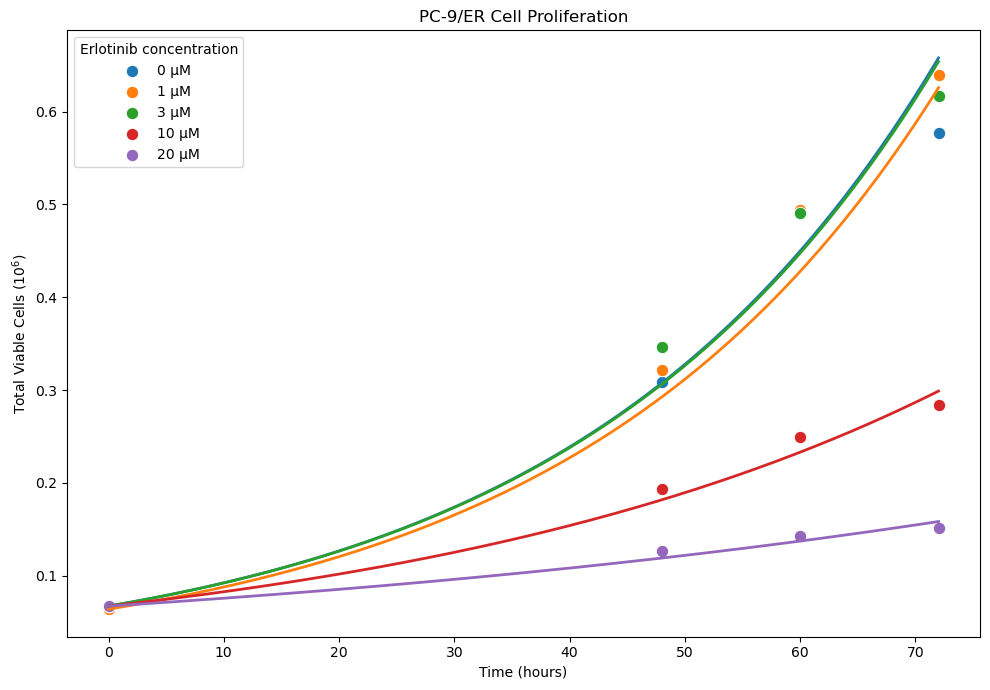

In [50]:
# sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

concentrations = sorted(df[concentration_col_name].unique())

# Get Seaborn's default color cycle
colors = sns.color_palette()

# Create mapping: concentration -> color
color_map = {
    concentration: colors[i % len(colors)]
    for i, concentration in enumerate(concentrations)
}

for concentration_value in concentrations:

    subset = df[
        df[concentration_col_name] == concentration_value
    ]

    sns.scatterplot(
        data=subset,
        x=time_col_name,
        y=total_cells_col_name,
        color=color_map[concentration_value],
        s=80,
        label=f"{concentration_value} µM"
    )

time_grid = np.linspace(
    df[time_col_name].min(),
    df[time_col_name].max(),
    300
)

for concentration_value in concentrations:

    model_values = tumor_model(
        best_params,
        time_grid,
        np.full_like(time_grid, concentration_value),
        phi
    )

    plt.plot(
        time_grid,
        model_values,
        color=color_map[concentration_value],
        linewidth=2
    )


plt.xlabel("Time (hours)")
plt.ylabel("Total Viable Cells ($10^6$)")

plt.title(
    f"PC-9/ER Cell Proliferation"
)

plt.legend(
    title="Erlotinib concentration"
)

plt.tight_layout()
plt.show()

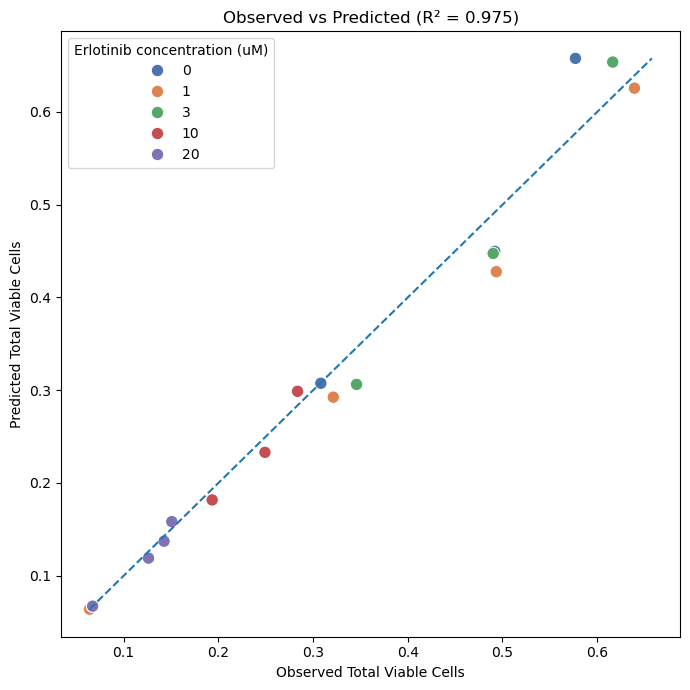

In [51]:
concentrations = sorted(df[concentration_col_name].unique())

colors = sns.color_palette("deep", n_colors=len(concentrations))

color_map = dict(zip(concentrations, colors))

plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=df,
    x=total_cells_col_name,
    y="predicted",
    hue=concentration_col_name,
    palette=color_map,
    s=80
)

min_value = min(
    df[total_cells_col_name].min(),
    df["predicted"].min()
)

max_value = max(
    df[total_cells_col_name].max(),
    df["predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Observed Total Viable Cells")
plt.ylabel("Predicted Total Viable Cells")
plt.title(f"Observed vs Predicted (R² = {R_squared:.3f})")

plt.tight_layout()
plt.show()